# Case Study on Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import math
from sklearn.model_selection import train_test_split

## Dataset Overview

Load the dataset House_Pricing.csv
Display basic information about the dataset using .info() and .describe() to understand the features, data types, and any initial insights into missing values.

In [2]:
# Load the Dataset
df=pd.read_csv("House_Pricing.csv")

In [3]:
df.shape
df.columns

Index(['ID', 'Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [4]:
# Display basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [5]:
# Display statistical summary
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [6]:
# Check first few rows
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


## Duplicate Removal

Rows: Check for duplicate rows in the dataset, if any, and remove them.
Columns: Identify and drop duplicate columns, if any, based on their values.

In [7]:
# Check number of duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
df['ID'].duplicated().sum() # Duplicate IDs exist but represent multiple transactions,
                            # so they should not be removed.

np.int64(177)

In [9]:
df.drop(columns=['ID']).duplicated().sum()

np.int64(2)

In [10]:
df[df['ID'].duplicated(keep=False)].sort_values('ID')

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
2496,1000102,14 September 2017,280000.0,6,3.00,2400.0,9373.0,2.0,No,NaN,...,7,2400.0,0,27,0,98002.0,47.3262,-122.214,2060.0,7316
2497,1000102,15 April 2016,300000.0,6,3.00,2400.0,9373.0,2.0,No,NaN,...,7,2400.0,0,27,0,98002.0,47.3262,-122.214,2060.0,7316
16814,7200179,14 October 2017,150000.0,2,1.00,840.0,12750.0,1.0,No,NaN,...,6,840.0,0,93,0,98055.0,47.4840,-122.211,1480.0,6969
16815,7200179,15 April 2016,175000.0,2,1.00,840.0,12750.0,1.0,No,NaN,...,6,840.0,0,93,0,98055.0,47.4840,-122.211,1480.0,6969
11433,109200390,14 August 2017,245000.0,3,1.75,1480.0,3900.0,1.0,No,NaN,...,7,1480.0,0,38,0,98023.0,47.2977,-122.367,1830.0,6956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6345,9828200460,14 June 2017,260000.0,2,1.00,700.0,4800.0,1.0,No,NaN,...,7,700.0,0,96,0,98122.0,47.6147,-122.300,1440.0,4800
15200,9834200305,15 February 2016,615000.0,3,1.00,1790.0,3876.0,1.5,No,NaN,...,7,1090.0,700,114,0,98144.0,47.5750,-122.288,1360.0,4080
15199,9834200305,14 July 2017,350000.0,3,1.00,1790.0,3876.0,1.5,No,NaN,...,7,1090.0,700,114,0,98144.0,47.5750,-122.288,1360.0,4080
1086,9834200885,15 April 2016,550000.0,4,2.50,2080.0,4080.0,1.0,No,NaN,...,7,1040.0,1040,56,0,98144.0,47.5720,-122.290,1340.0,4080


In [11]:
# Removing rows that are identical across all features except ID
# because ID represents transaction, not unique house record
df = df.drop_duplicates(subset=df.columns.difference(['ID']))

In [12]:
df.drop(columns=['ID']).duplicated().sum()

np.int64(0)

In [13]:
# check duplicate columns
duplicate_cols = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            duplicate_cols.append(df.columns[j])

duplicate_cols

[]

In [14]:
# Shape check
df.shape

(21611, 21)

## Handling Missing Values

Identify missing values in each column.
Handle missing values:
For numerical columns, use imputation techniques like mean/median imputation.
For categorical columns, fill with mode.
Document your approach for each feature with missing data.

In [15]:
# ===============================
# 1. CHECK MISSING VALUES
# ===============================
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    '% Missing': missing_percentage
})

print("Missing Value Summary:")
print(missing_info[missing_info['Missing Values'] > 0]
      .sort_values(by='% Missing', ascending=False))

Missing Value Summary:
                                           Missing Values  % Missing
No of Times Visited                                 19487  90.171672
Flat Area (in Sqft)                                     9   0.041645
Lot Area (in Sqft)                                      9   0.041645
Sale Price                                              4   0.018509
No of Bathrooms                                         4   0.018509
Area of the House from Basement (in Sqft)               3   0.013882
Zipcode                                                 1   0.004627
Latitude                                                1   0.004627
Longitude                                               1   0.004627
Living Area after Renovation (in Sqft)                  1   0.004627


In [16]:
# ===============================
# 2. DROP HIGHLY MISSING COLUMN
# ===============================
# ~90% missing then it is not useful
df = df.drop(columns=['No of Times Visited'])

In [17]:
# ===============================
# 3. HANDLE TARGET VARIABLE
# ===============================
# Never impute target, so drop missing rows
df = df[df['Sale Price'].notnull()]

Skewness of selected columns:

Flat Area (in Sqft): 1.47
Lot Area (in Sqft): 13.06
Area of the House from Basement (in Sqft): 1.45
Living Area after Renovation (in Sqft): 1.11
No of Bathrooms: 0.51
Latitude: -0.49
Longitude: 0.88


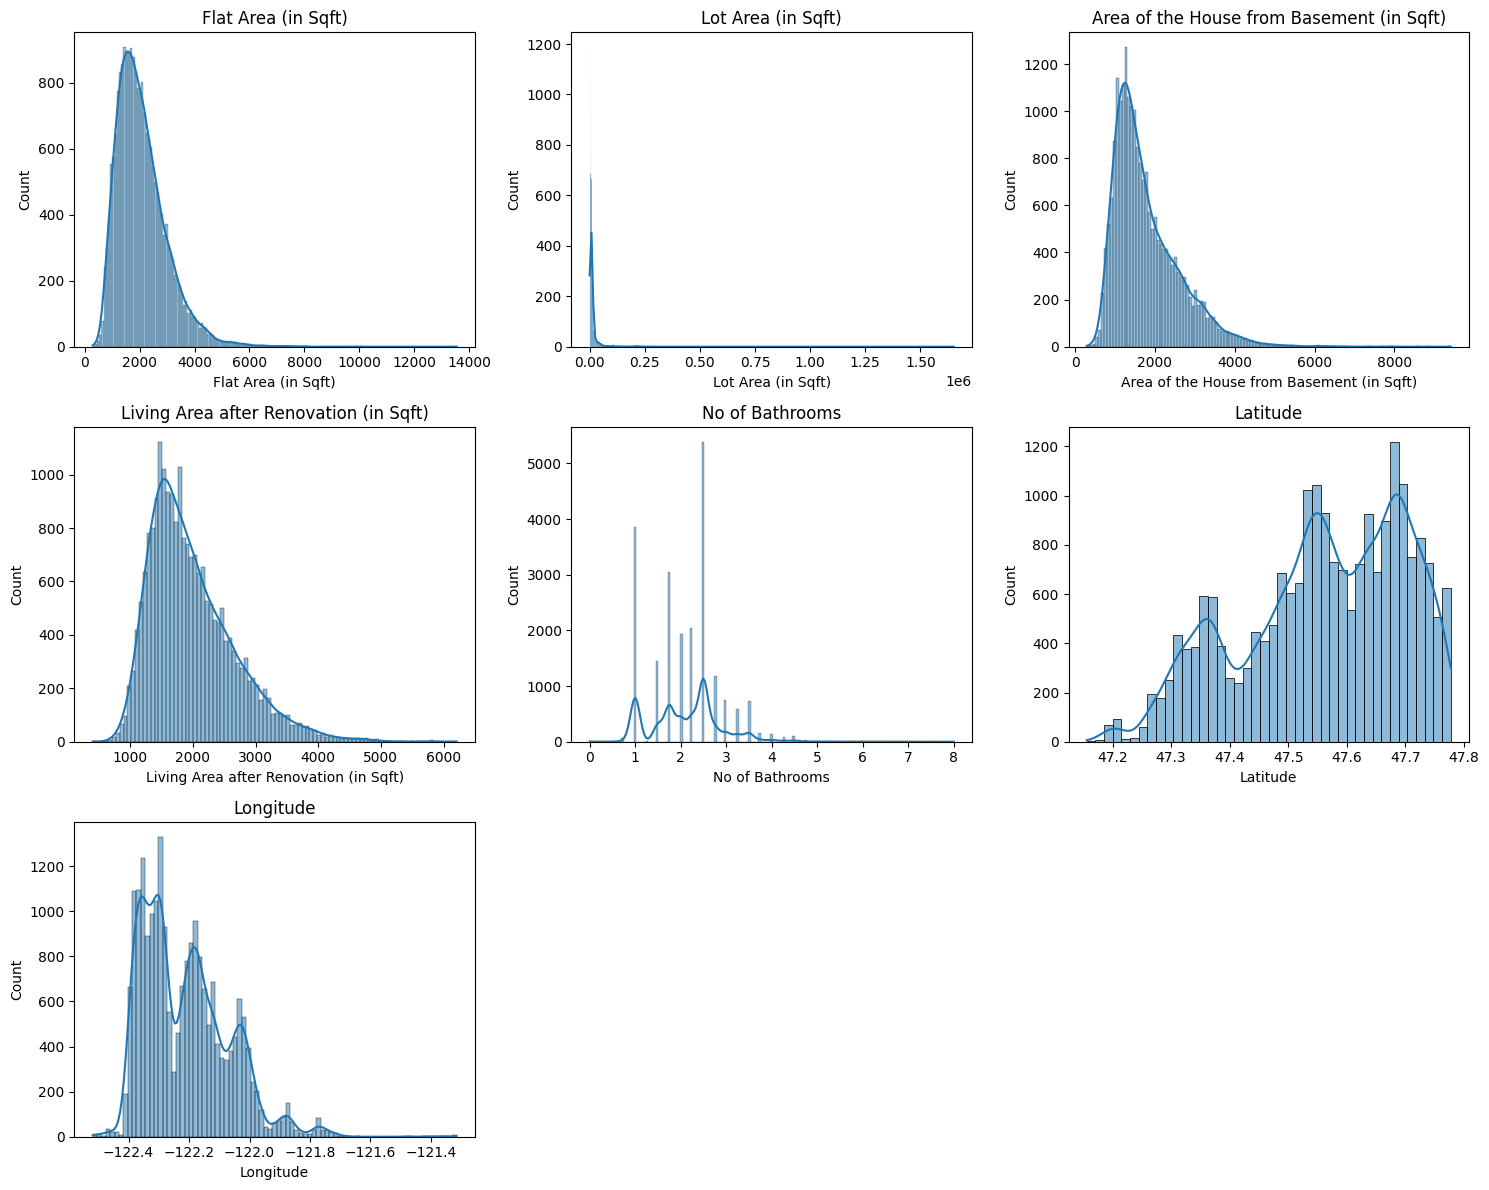

In [18]:
# ===============================
# 4. CHECK DISTRIBUTION + SKEWNESS (WITH SUBPLOTS)
# ===============================
columns_to_check = [
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Living Area after Renovation (in Sqft)',
    'No of Bathrooms',
    'Latitude',
    'Longitude'
]

print("Skewness of selected columns:\n")

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(columns_to_check):
    skew_val = df[col].skew()
    print(f"{col}: {skew_val:.2f}")

    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col}")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [19]:
# NOTE:
# 'Lot Area (in Sqft)' has extremely high skewness (~13),
# which indicates presence of extreme outliers.
# Median imputation is used here for robustness.
# Additionally, log transformation may be applied later
# to normalize the distribution for better model performance.

In [20]:
# ===============================
# 4.1 CATEGORICAL COLUMN CHECK
# ===============================
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols)

# Check missing values in categorical columns
cat_missing = df[categorical_cols].isnull().sum()

print("\nMissing Values in Categorical Columns:")
print(cat_missing[cat_missing > 0])

if cat_missing.sum() == 0:
    print("\nNo missing values in categorical features.")

Categorical Columns:
Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')

Missing Values in Categorical Columns:
Series([], dtype: int64)

No missing values in categorical features.


In [21]:
# ===============================
# 5. NUMERICAL IMPUTATION
# ===============================

# Median for highly skewed features
skewed_cols = [
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Living Area after Renovation (in Sqft)'
]

for col in skewed_cols:
    df[col] = df[col].fillna(df[col].median())

In [22]:
# Bathrooms => slightly skewed => median safer
df['No of Bathrooms'] = df['No of Bathrooms'].fillna(df['No of Bathrooms'].median())

In [23]:
# Latitude => near normal => mean
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].mean())

In [24]:
# Longitude => moderate skew => using median (better choice)
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].median())

In [25]:
# ===============================
# 6. HANDLE ZIPCODE (CATEGORICAL)
# ===============================
# Even though numeric => acts like category => use mode
df['Zipcode'] = df['Zipcode'].fillna(df['Zipcode'].mode()[0])

In [26]:
# ===============================
# 7. FINAL CHECK
# ===============================
final_missing = df.isnull().sum()

print("Final Missing Values:")
print(final_missing[final_missing > 0])

if final_missing.sum() == 0:
    print("\nAll missing values successfully handled!")

Final Missing Values:
Series([], dtype: int64)

All missing values successfully handled!


In [27]:
# ===============================
# 8. FINAL SHAPE
# ===============================
print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (21607, 20)


In [28]:
# ===============================
# 8. PIPELINE CONSISTENCY
# ===============================

# NOTE:
# In real-world machine learning pipelines:
# - Imputation values (mean/median/mode) must be calculated ONLY on training data
# - The same values are then applied to test data

# Example workflow:
# 1. Split data into train and test
# 2. Fit imputer on training set
# 3. Transform both train and test using same imputer

# This prevents data leakage and ensures model generalization.

## Scaling Numerical Variables

Scaling Numerical Variables
Identify all numerical columns (excluding the target variable SalePrice).
Scale these features using techniques like Min-Max scaling or Standard scaling.

In [29]:
# -------------------------------
# 1. Separate Features and Target
# -------------------------------
X = df.drop(columns=['Sale Price'])   # Features
y = df['Sale Price']                  # Target

In [30]:
# -------------------------------
# 2. Train-Test Split (IMPORTANT)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
# -------------------------------
# 3. Identify Numerical Columns
# -------------------------------
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Exclude:
# - ID : identifier (no learning value)
# - Zipcode : categorical (even though numeric)
# - Renovated Year  year-based feature, scaling may not add meaningful value
columns_to_scale = [
    col for col in numerical_cols
    if col not in ['ID', 'Zipcode', 'Renovated Year']
]

print("Columns to be scaled:")
print(columns_to_scale)

Columns to be scaled:
['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade', 'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)', 'Age of House (in Years)', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)']


In [32]:
# -------------------------------
# 4. Apply Standard Scaling
# -------------------------------

# StandardScaler is used because most numerical features are
# approximately normally distributed after preprocessing.
# It transforms data to mean = 0 and standard deviation = 1.

scaler = StandardScaler()

# Alternative scaling techniques:
# - MinMaxScaler: Scales values between 0 and 1, useful when distribution is not Gaussian
# - RobustScaler: Uses median and IQR, suitable for data with strong outliers

# Choice of scaler depends on data distribution:
# - StandardScaler : best for normally distributed data
# - MinMaxScaler : useful for bounded data (e.g., images, neural networks)
# - RobustScaler  preferred when dataset contains significant outliers


# Fit only on training data
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

# Transform test data using same scaler
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [33]:
# -------------------------------
# 5. Verify Scaling
# -------------------------------
print("Summary of scaled features (Training Data):")
print(X_train[columns_to_scale].describe().loc[['mean', 'std']])

Summary of scaled features (Training Data):
      No of Bedrooms  No of Bathrooms  Flat Area (in Sqft)  \
mean    1.946439e-16     2.178696e-16        -2.378068e-16   
std     1.000029e+00     1.000029e+00         1.000029e+00   

      Lot Area (in Sqft)  No of Floors  Overall Grade  \
mean        1.407931e-17  5.631724e-17   2.741869e-16   
std         1.000029e+00  1.000029e+00   1.000029e+00   

      Area of the House from Basement (in Sqft)  Basement Area (in Sqft)  \
mean                               4.336839e-17            -1.767622e-17   
std                                1.000029e+00             1.000029e+00   

      Age of House (in Years)      Latitude     Longitude  \
mean            -3.946318e-17  8.578956e-14  8.638613e-14   
std              1.000029e+00  1.000029e+00  1.000029e+00   

      Living Area after Renovation (in Sqft)  \
mean                           -1.286664e-16   
std                             1.000029e+00   

      Lot Area after Renovation (in Sqf

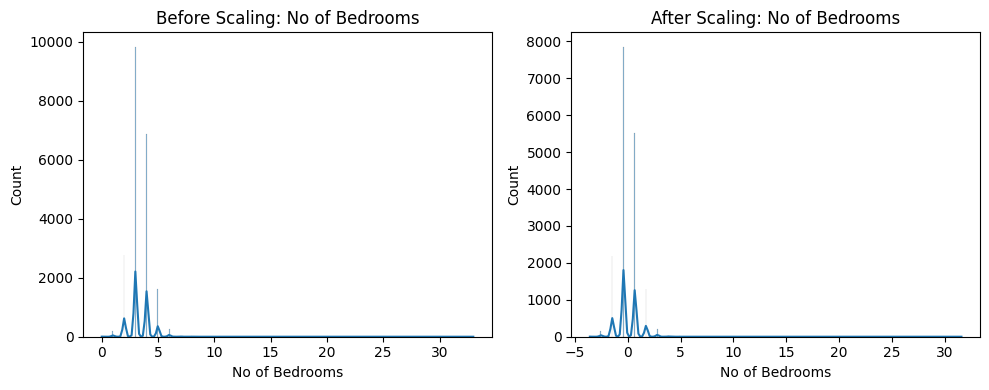

In [34]:
# -------------------------------
# Visual Check (Before vs After)
# -------------------------------
col_example = columns_to_scale[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df[col_example], kde=True)
plt.title(f"Before Scaling: {col_example}")

plt.subplot(1,2,2)
sns.histplot(X_train[col_example], kde=True)
plt.title(f"After Scaling: {col_example}")

plt.tight_layout()
plt.show()

In [35]:
# -------------------------------
# 7. Final Output Shapes
# -------------------------------
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (17285, 19)
Test Shape: (4322, 19)


## Encoding Categorical Variables

Identify all categorical columns in the dataset.
Apply appropriate encoding techniques:
Use One-Hot Encoding for nominal categories.
Use Label Encoding for ordinal categories, if applicable.

In [36]:
# ---------------------------------------------------------
# TYPES OF ENCODING (REFERENCE)
# ---------------------------------------------------------
# 1. One-Hot Encoding  : For nominal categories (no order)
# 2. Ordinal Encoding  : For ordered categories (with rank)
# 3. Label Encoding    : Mostly for target variable or tree-based models

In [37]:
# =========================================================
# 1. HANDLE DATE COLUMN (FEATURE ENGINEERING)
# =========================================================

# Convert to datetime format
df['Date House was Sold'] = pd.to_datetime(df['Date House was Sold'])

# Extract useful features
df['Sale_Year'] = df['Date House was Sold'].dt.year
df['Sale_Month'] = df['Date House was Sold'].dt.month
df['Sale_Day_of_Week'] = df['Date House was Sold'].dt.dayofweek

# Optional: Weekend feature (advanced feature engineering)
df['Is_Weekend'] = df['Sale_Day_of_Week'].isin([5, 6]).astype(int)

# Drop original column (no longer needed)
df.drop('Date House was Sold', axis=1, inplace=True)

print("Date column processed and new features created.")

Date column processed and new features created.


In [38]:
# =========================================================
# 2. ONE-HOT ENCODING (Nominal Feature)
# =========================================================

# 'Waterfront View' : binary nominal feature (Yes/No)
df = pd.get_dummies(df, columns=['Waterfront View'], prefix='Waterfront', drop_first=True)

# Convert boolean to integer (0/1)
df['Waterfront_Yes'] = df['Waterfront_Yes'].astype(int)

print("'Waterfront View' one-hot encoded.")

'Waterfront View' one-hot encoded.


In [39]:
# =========================================================
# 3. ORDINAL ENCODING (Ordered Feature)
# =========================================================

# Check unique values first
print("Unique values in 'Condition of the House':")
print(df['Condition of the House'].value_counts())

# Correct logical order:
# Bad < Fair < Okay < Good < Excellent
condition_mapping = {
    'Bad': 0,
    'Fair': 1,
    'Okay': 2,
    'Good': 3,
    'Excellent': 4
}

Unique values in 'Condition of the House':
Condition of the House
Fair         14026
Good          5678
Excellent     1701
Okay           172
Bad             30
Name: count, dtype: int64


In [40]:
# Apply mapping
df['Condition of the House'] = df['Condition of the House'].map(condition_mapping)

# Check if mapping created any missing values (IMPORTANT)
missing_after_mapping = df['Condition of the House'].isnull().sum()

if missing_after_mapping > 0:
    print(f"Warning: {missing_after_mapping} values became NaN after mapping!")
else:
    print("Ordinal encoding applied successfully with no missing values.")

Ordinal encoding applied successfully with no missing values.


In [41]:
# =========================================================
# 4. FINAL VALIDATION
# =========================================================

# Check if any categorical columns remain
remaining_categorical = df.select_dtypes(include='object').columns

print("Remaining Categorical Columns:")
print(remaining_categorical)

if len(remaining_categorical) == 0:
    print("All categorical variables successfully encoded!")
else:
    print("Some categorical variables still need encoding.")

Remaining Categorical Columns:
Index([], dtype='object')
All categorical variables successfully encoded!


In [42]:
# =========================================================
# 5. FINAL DATA PREVIEW
# =========================================================
print("Final Dataset Preview:")
display(df.head())

Final Dataset Preview:


,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year,Sale_Month,Sale_Day_of_Week,Is_Weekend,Waterfront_Yes
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,1,7,1180.0,...,98178.0,47.5112,-122.257,1340.0,5650,2017,10,5,1,0
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,1,7,2170.0,...,98125.0,47.7210,-122.319,1690.0,7639,2017,12,3,0,0
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,1,6,770.0,...,98028.0,47.7379,-122.233,2720.0,8062,2016,2,0,0,0
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,4,7,1050.0,...,98136.0,47.5208,-122.393,1360.0,5000,2017,12,3,0,0
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,1,8,1680.0,...,98074.0,47.6168,-122.045,1800.0,7503,2016,2,0,0,0


In [43]:
# LabelEncoder is not used here because it introduces artificial order
# in nominal features, which can mislead models.
# Note: Tree-based models (like Random Forest) can handle label encoding
# better, but for linear models, proper encoding is important.

## Outlier Removal

Perform an outlier detection analysis on numerical variables (e.g., using the IQR method).
Remove outliers from these features if they are not representative of typical house prices.

In [44]:
# NOTE:
# - We DO NOT remove outliers from target variable (Sale Price)
# - We DO NOT apply IQR on binary or categorical features
# - We ONLY handle true continuous numerical features
# - We avoid aggressive row deletion to prevent data loss
# Outlier handling is especially important for models like
# Linear Regression and KNN, which are sensitive to extreme values.

In [45]:
# =========================================================
# 1. IDENTIFY NUMERICAL COLUMNS
# =========================================================

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Exclude columns where outlier removal is NOT appropriate
exclude_cols = [
    'ID',                        # Identifier
    'Zipcode',                   # Categorical disguised as numeric
    'Sale Price',                # Target variable (IMPORTANT: do not remove)
    'Is_Weekend',                # Binary feature
    'Waterfront_Yes',            # Binary feature
    'Condition of the House',    # Ordinal categorical
    'Sale_Year',
    'Sale_Month',
    'Sale_Day_of_Week',
    'Renovated Year',             # Year-based feature
    'Overall Grade'
]

# Final columns where IQR can be safely applied
columns_for_outliers = [
    col for col in numerical_cols if col not in exclude_cols
]

print("Columns selected for outlier handling:")
print(columns_for_outliers)

Columns selected for outlier handling:
['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors', 'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)', 'Age of House (in Years)', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)']


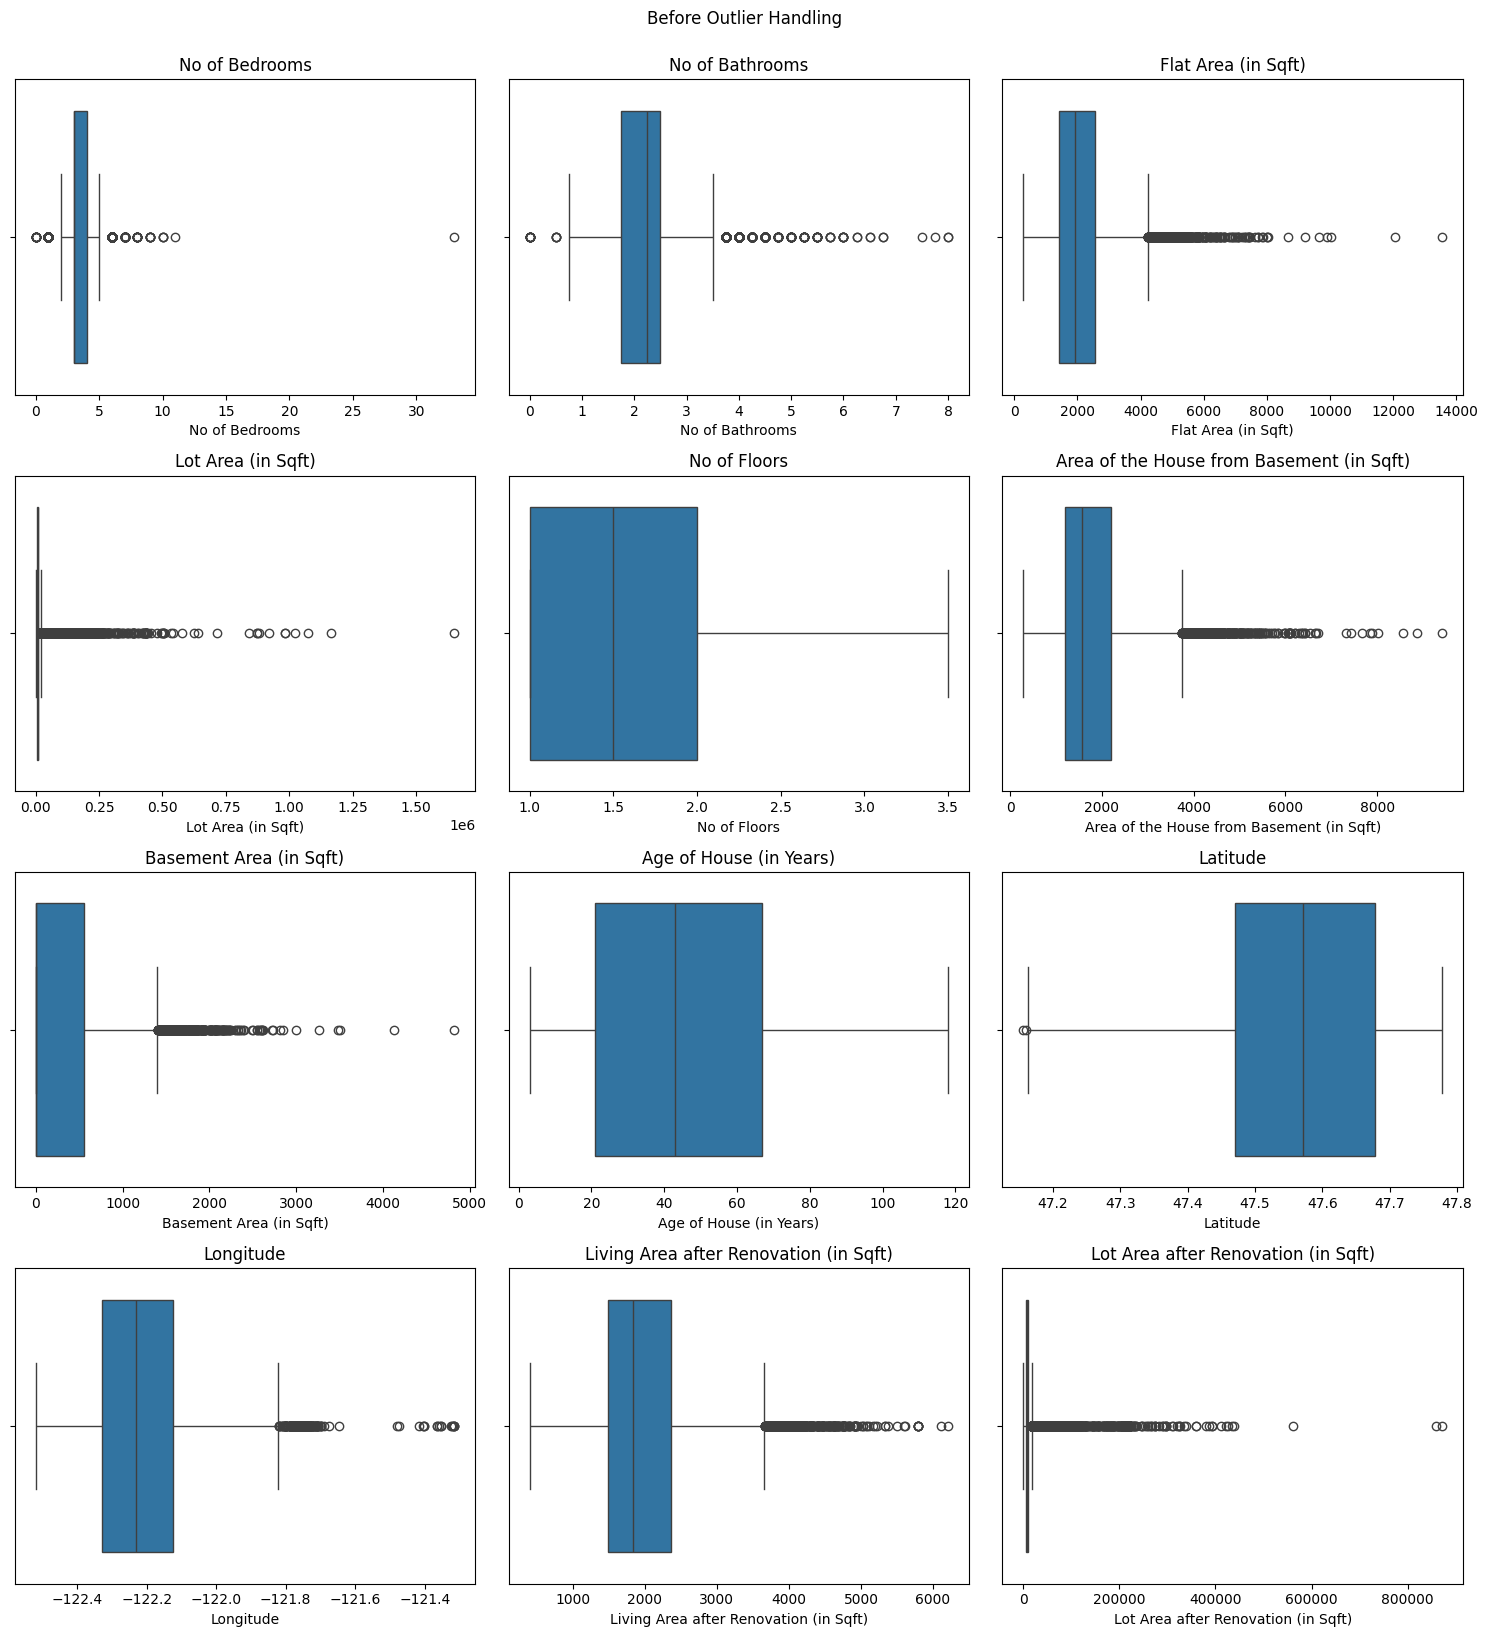

In [46]:
# =========================================================
# 2. VISUAL CHECK
# =========================================================

# Boxplots help visually confirm presence of outliers
cols = columns_for_outliers
n = len(cols)

rows = math.ceil(n / 3)

plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(cols):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"{col}")

plt.tight_layout()
plt.suptitle("Before Outlier Handling", y=1.02)
plt.show()

In [47]:
# Removing rows can lead to significant data loss,
# especially when dataset size is moderate.
# Hence, capping is preferred.

In [48]:
# =========================================================
# 3. IQR-BASED OUTLIER CAPPING (WINSORIZATION)
# =========================================================

# Instead of removing rows, we CAP extreme values
# This preserves data while reducing outlier impact

def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before capping
    outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    # Apply capping
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

    if outliers_count > 0:
        print(f"Capped {outliers_count} outliers in '{column}'")

    return df


# Apply capping to all selected columns
for col in columns_for_outliers:
    df = cap_outliers_iqr(df, col)

Capped 545 outliers in 'No of Bedrooms'
Capped 571 outliers in 'No of Bathrooms'
Capped 572 outliers in 'Flat Area (in Sqft)'
Capped 2423 outliers in 'Lot Area (in Sqft)'
Capped 610 outliers in 'Area of the House from Basement (in Sqft)'
Capped 496 outliers in 'Basement Area (in Sqft)'
Capped 2 outliers in 'Latitude'
Capped 256 outliers in 'Longitude'
Capped 544 outliers in 'Living Area after Renovation (in Sqft)'
Capped 2193 outliers in 'Lot Area after Renovation (in Sqft)'


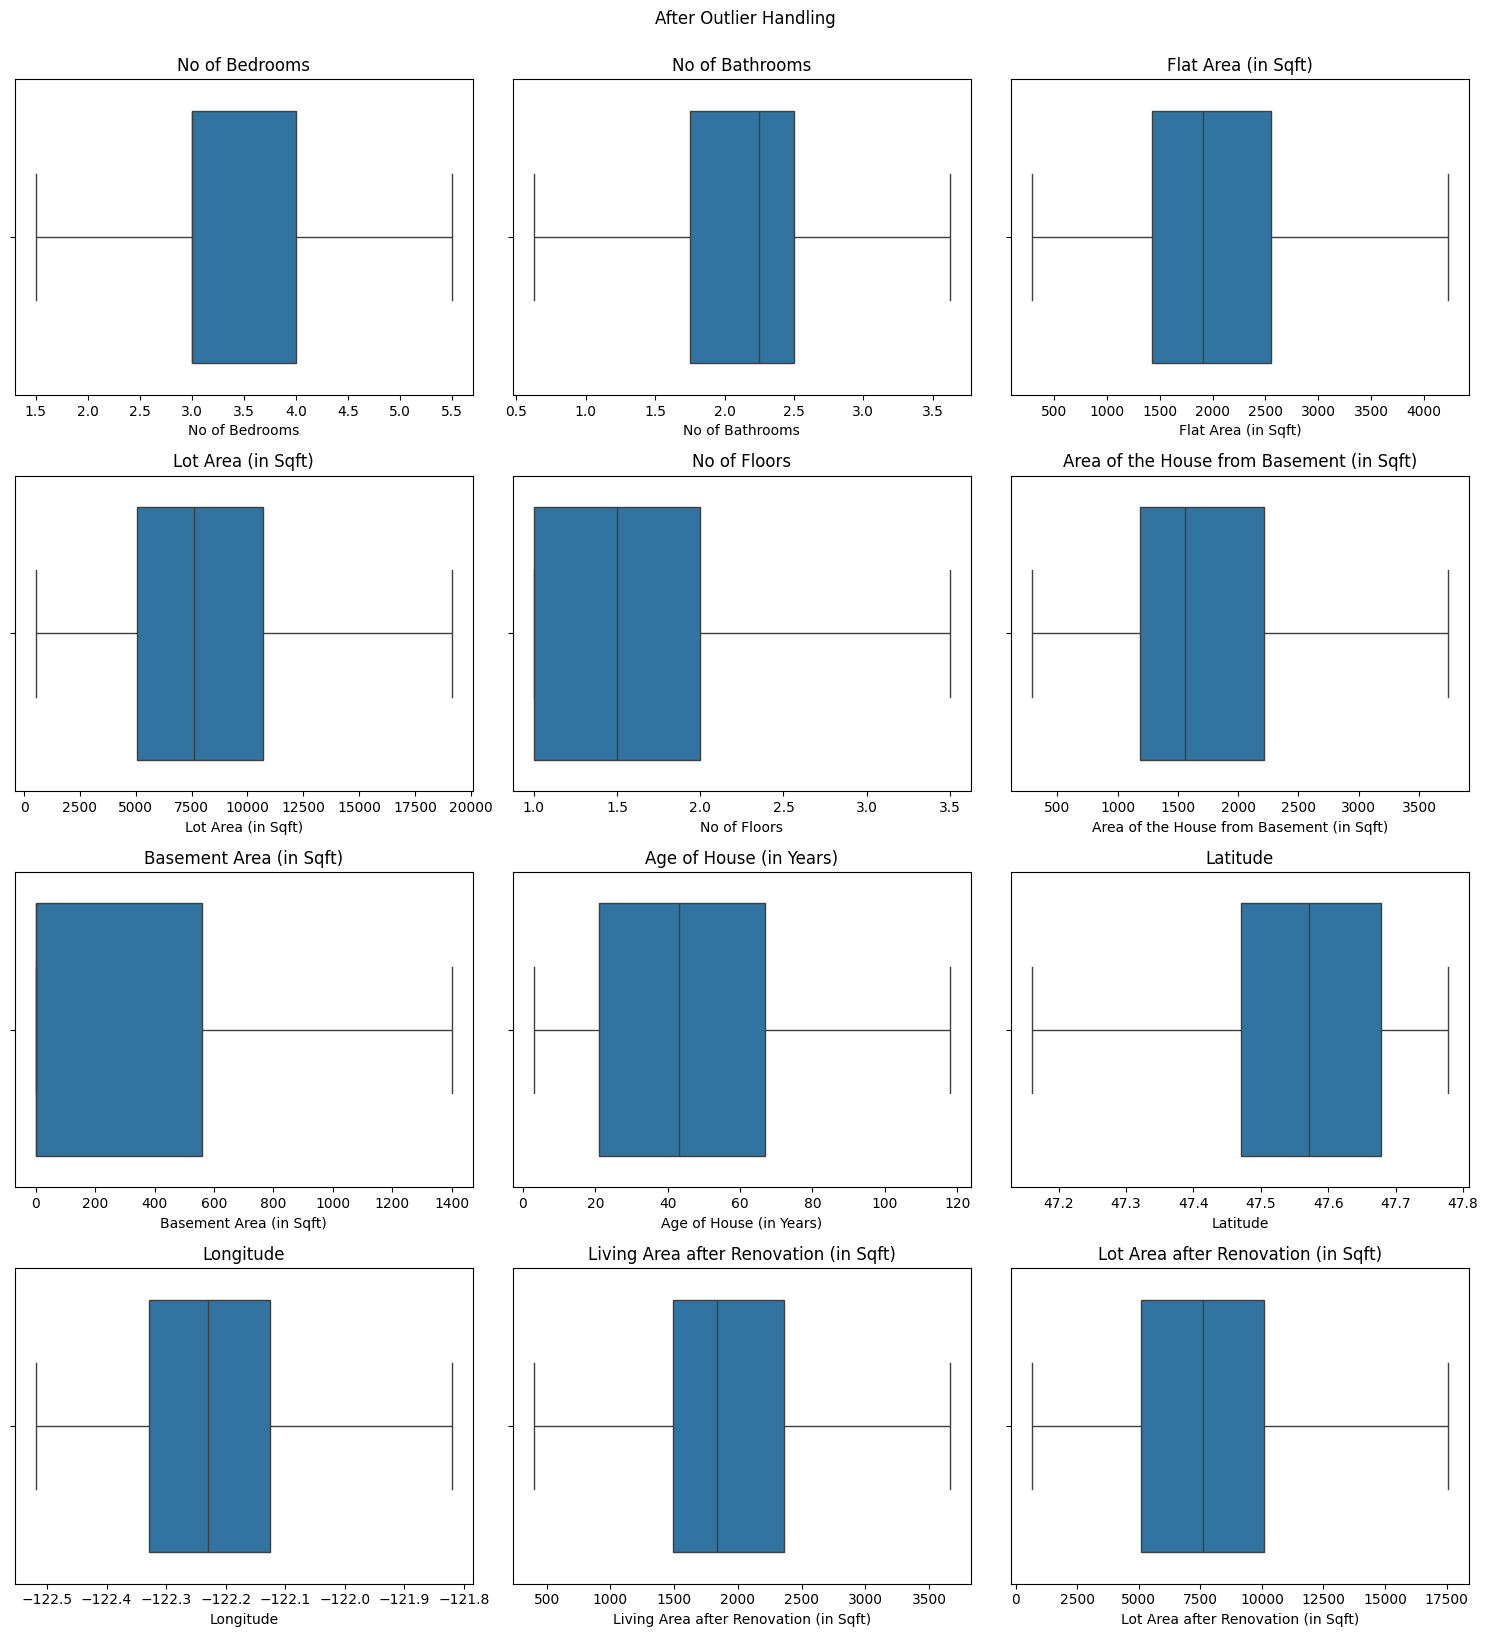

In [49]:
plt.figure(figsize=(15, 4 * rows))

for i, col in enumerate(cols):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"{col}")

plt.tight_layout()
plt.suptitle("After Outlier Handling", y=1.02)
plt.show()

In [50]:
# =========================================================
# 4. LOG TRANSFORMATION FOR HIGHLY SKEWED FEATURES
# =========================================================

# Especially useful for features like Lot Area (very high skew)

import numpy as np

highly_skewed_cols = [
    'Lot Area (in Sqft)',
    'Lot Area after Renovation (in Sqft)'
]

for col in highly_skewed_cols:
    if col in df.columns:
        df[col] = np.log1p(df[col])  # log(1 + x) to handle zero values
        print(f"Applied log transformation to '{col}'")


Applied log transformation to 'Lot Area (in Sqft)'
Applied log transformation to 'Lot Area after Renovation (in Sqft)'


In [51]:
# =========================================================
# 5. FINAL CHECK
# =========================================================

print("Final dataset shape (after outlier handling):", df.shape)

print("\nSummary statistics after outlier handling:")
display(df[columns_for_outliers].describe())

Final dataset shape (after outlier handling): (21607, 23)

Summary statistics after outlier handling:


,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,21607.000000,21607.000000,21607.000000,21607.000000,21607.000000,21607.000000,21607.000000,21607.000000,21607.000000,21607.000000,21607.000000,21607.000000
mean,3.362822,2.098423,2058.003934,8.883246,1.494122,1769.567085,284.063313,47.003425,47.560051,-122.214871,1975.174897,8.868442
std,0.853981,0.721978,838.881472,0.662748,0.539826,763.927528,417.070044,29.372141,0.138562,0.137209,649.023500,0.600031
min,1.500000,0.625000,290.000000,6.255750,1.000000,290.000000,0.000000,3.000000,47.160375,-122.519000,399.000000,6.480045
25%,3.000000,1.750000,1430.000000,8.525856,1.000000,1190.000000,0.000000,21.000000,47.470950,-122.328000,1490.000000,8.537192
50%,3.000000,2.250000,1910.000000,8.938663,1.500000,1560.000000,0.000000,43.000000,47.571800,-122.230000,1840.000000,8.938663
75%,4.000000,2.500000,2550.000000,9.276924,2.000000,2210.000000,560.000000,67.000000,47.678000,-122.125000,2360.000000,9.218904
max,5.500000,3.625000,4230.000000,9.860371,3.500000,3740.000000,1400.000000,118.000000,47.777600,-121.820500,3665.000000,9.773578


## Train-Test Split

Set aside the SalePrice column as the target variable.
Split the dataset into training (80%) and testing (20%) sets using the train_test_split function from sklearn.

In [52]:
# ---------------------------------------------------------
# 1. DEFINE FEATURES (X) AND TARGET (y)
# ---------------------------------------------------------
# 'Sale Price' is the target variable (what we want to predict)
# All other columns are used as input features

X = df.drop('Sale Price', axis=1)   # Features
y = df['Sale Price']                # Target

In [53]:
# ---------------------------------------------------------
# 2. SPLIT DATA INTO TRAINING AND TESTING SETS
# ---------------------------------------------------------
# We split the dataset to evaluate model performance on unseen data

# Parameters:
# - test_size=0.2 → 20% data for testing, 80% for training
# - random_state=42 → ensures reproducibility (same split every run)
# - shuffle=True → randomly shuffles data before splitting (default behavior)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [54]:
# ---------------------------------------------------------
# 3. VERIFY THE SPLIT
# ---------------------------------------------------------
print("Dataset successfully split into training and testing sets.\n")

print("Training Set:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}\n")

print("Testing Set:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


Dataset successfully split into training and testing sets.

Training Set:
X_train shape: (17285, 22)
y_train shape: (17285,)

Testing Set:
X_test shape: (4322, 22)
y_test shape: (4322,)


In [55]:
# ---------------------------------------------------------
# 4. NOTE
# ---------------------------------------------------------
# - Always perform preprocessing (scaling, imputation, encoding)
#   using ONLY the training data.
# - Then apply the same transformations to the test data.
# - This prevents data leakage and ensures realistic model evaluation.